<a href="https://colab.research.google.com/github/pguillo02/MIAR-Algoritmos_de_optimizaci-n/blob/main/Trabajo_Pr%C3%A1ctico_Algoritmos(V2%2Cno_borrar).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Pablo Guilló Jiménez <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/17i0mWbFAyOchB0oxrs4GQ7t12pzuTDAZ?usp=sharing<br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:(copiar enunciado)

....







                                        

# Organizar los horarios de partidos de La Liga mediante la técnica de divide y venceras


La idea central de este proyecto es organizar los partidos de la liga profesional de fútbol mediante la técnica de optimización divide y venceras. En este caso debemos asignar franjas horarias a diez partidos en función de una serie de limitaciones que se explicarán más adelante.


## Modelización

Como se comentó con anterioridad, el problema nos pide crear un horario para una liga de fútbol compuesta por 20 equipos. Cada uno de estos equipos es asignado a un grupo de popularidad, A, B y C en función del número de fans y la atención que generan. 3 de estos equipos pertenecen al grupo A, 11 al B y 6 al C. La asistencia promedio de los partidos varia de manera aproximada en función los equipos participantes siguiendo las siguientes métricas:

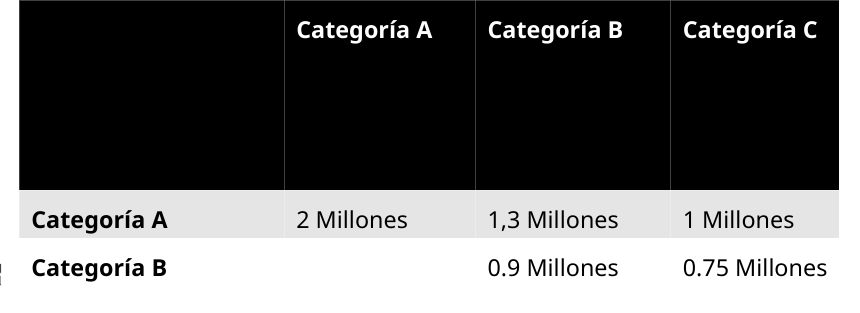

Contamos con 10 franjas horarias distintas y tenemos que tener en cuenta que de manera obligatoria a de presentarse por lo menos un partido el viernes y un partido el lunes. Las franjas disponibles son las siguientes:

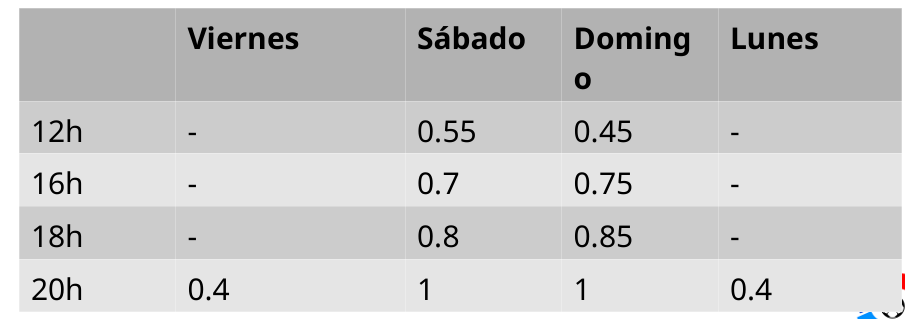

Además, pueden existir partidos coincidentes, es decir, que compartan el mismo horario. Sin embargo, esto provoca una reducción promedio de la audiencia basada en los siguientes coeficientes:

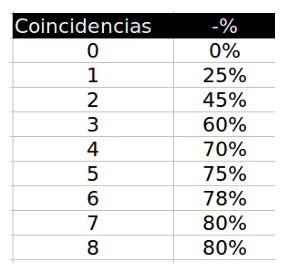

### Representación

La forma más básicas y eficiente de representar los horarios seleccionados es a través de un vector con tantos elementos como partidos. A las distintas franjas horarias se les asignará un código determinado y cada posición en el vector correspondará con un partido. Ejemplo: [1,2,4,3,5,6,7,8,8,9]. De esta manera podemos representar que horario toma cada partido y si existen coincidencias en el mismo.


### Función objetivo

La función objetivo es la encargada de determinar el rendimiento de una determinada solución, por lo que nuestro objetivo será maximizarla o minimizarla en función de nuestro problema. En este caso, la función objetivo buscará maximizar la asistencia de la jornada en su totalidad y deberá tener en cuenta los equipos que juegan en cada partido, los horarios asignados y las posibles coincidencias. Es por esto que tendrá una forma del tipo:

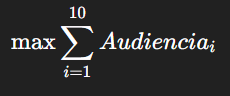

### Restricciones

Las restricciones en este caso son claras; Debe existir un partido el viernes y un partido el lunes, contamos obligatoriamente con 10 partidos a repartir, y los partidos coincidentes sufrirán penalización teniendo en cuenta las ponderaciones previamente marcadas.

## Análisis

Teniendo en cuenta las características del problema previamente mencionadas, a nivel combinatorio contamos con 10^10 combinaciones, totalmente inabarcables en cirscuntancias normales al tratarse de complejidad exponencial O(k^n). Al emplear la técnica de divide y venceras, más concretamente con man in the middle, dividimos recursivamente la complejidad a medida que partimos el problema. Además, las restricciones en cuanto a el horario marcado nos permiten podar el árbol de búsqueda, reduciendo la cantidad de operaciones.


## Diseño e implementacióbn

Implementar el algoritmo de resolución en python de una manera clara implica moduralizar el código en varias funciones. En primer lugar definimos los datos necesarios, entre ellos los horarios, los coeficientes de penalización y las audiencias estimadas en función de los equipos

In [1]:
from itertools import product

HORARIOS = {
    0: "V20",
    1: "S12",
    2: "S16",
    3: "S18",
    4: "S20",
    5: "D12",
    6: "D16",
    7: "D18",
    8: "D20",
    9: "L20"
}

COEF_HORARIO = {
    0: 0.4,   # V20
    1: 0.55,  # S12
    2: 0.7,   # S16
    3: 0.8,   # S18
    4: 1.0,   # S20
    5: 0.45,  # D12
    6: 0.75,  # D16
    7: 0.85,  # D18
    8: 1.0,   # D20
    9: 0.4    # L20
}

BASE = {
    ("A", "A"): 2.0,
    ("A", "B"): 1.3,
    ("B", "A"): 1.3,
    ("A", "C"): 1.0,
    ("C", "A"): 1.0,
    ("B", "B"): 0.9,
    ("B", "C"): 0.75,
    ("C", "B"): 0.75,
    ("C", "C"): 0.47
}

PENALIZACION = {
    1: 1.0,
    2: 0.75,
    3: 0.55,
    4: 0.40
}

Con los datos ya definidos, implementamos la función objetivo, la función que genera las soluciones parciales, la que los recombina y varias funciones auxiliares que orquestan el método.

In [2]:
def audiencia_base(partido):
    cat1, cat2 = partido
    return BASE[(cat1, cat2)]

def evaluar_solucion_completa(partidos, asignacion):
    """
    partidos: lista de tuplas, ej. [("A","B"), ("C","C"), ...]
    asignacion: lista de horarios, ej. [0,4,6,9]
    """
    n = len(partidos)

    # Contar cuántos partidos hay en cada horario
    conteo = {h: 0 for h in HORARIOS}
    for h in asignacion:
        conteo[h] += 1

    # Restricción: exactamente un partido en viernes y uno en lunes
    if conteo[0] != 1 or conteo[9] != 1:
        return -1  # solución inválida

    total = 0.0
    for i in range(n):
        partido = partidos[i]
        h = asignacion[i]

        base = audiencia_base(partido)
        coef_h = COEF_HORARIO[h]
        num_en_franja = conteo[h]

        if num_en_franja not in PENALIZACION:
            return -1  # por si hubiera más coincidencias de las contempladas

        penal = PENALIZACION[num_en_franja]

        total += base * coef_h * penal

    return total

def generar_soluciones_parciales(partidos_sub, offset=0):
    """
    Genera TODAS las asignaciones posibles para un subconjunto de partidos.
    Devuelve una lista de diccionarios con información parcial.
    """
    k = len(partidos_sub)
    soluciones = []

    for asignacion_local in product(range(10), repeat=k):
        conteo = {h: 0 for h in HORARIOS}
        suma_parcial = 0.0

        for i, h in enumerate(asignacion_local):
            conteo[h] += 1
            suma_parcial += audiencia_base(partidos_sub[i]) * COEF_HORARIO[h]
            # Aquí NO aplicamos todavía penalización final global

        soluciones.append({
            "asignacion_local": list(asignacion_local),
            "conteo": conteo,
            "viernes": conteo[0],
            "lunes": conteo[9],
            "suma_sin_penal_global": suma_parcial
        })

    return soluciones

def combinar_y_evaluar(partidos, sol_izq, sol_der, tam_izq):
    mejor_valor = -1
    mejor_asignacion = None

    for s1 in sol_izq:
        for s2 in sol_der:
            # Restricción rápida
            if s1["viernes"] + s2["viernes"] != 1:
                continue
            if s1["lunes"] + s2["lunes"] != 1:
                continue

            asignacion_total = s1["asignacion_local"] + s2["asignacion_local"]
            valor = evaluar_solucion_completa(partidos, asignacion_total)

            if valor > mejor_valor:
                mejor_valor = valor
                mejor_asignacion = asignacion_total

    return mejor_valor, mejor_asignacion

def resolver_divide_venceras(partidos):
    mitad = len(partidos) // 2
    partidos_izq = partidos[:mitad]
    partidos_der = partidos[mitad:]

    sol_izq = generar_soluciones_parciales(partidos_izq)
    sol_der = generar_soluciones_parciales(partidos_der)

    mejor_valor, mejor_asignacion = combinar_y_evaluar(partidos, sol_izq, sol_der, mitad)
    return mejor_valor, mejor_asignacion

def mostrar_solucion(partidos, asignacion):
    print("Asignación final:")
    for i, h in enumerate(asignacion):
        print(f"Partido {i+1} {partidos[i]} -> {HORARIOS[h]}")
    print()
    print(f"Audiencia total = {evaluar_solucion_completa(partidos, asignacion):.4f}")

Con esto implementado podemos mostrar un ejemplo:

In [ ]:
partidos = [
    ("A", "A"),
    ("A", "B"),
    ("A", "C"),
    ("B", "B"),
    ("B", "C"),
    ("C", "C"),
    ("A", "B"),
    ("B", "B"),
    ("B", "C"),
    ("C", "C")
]

mejor_valor, mejor_asignacion = resolver_divide_venceras(partidos)
mostrar_solucion(partidos, mejor_asignacion)

En este ejemplo podemos apreciar los horarios finalmente asignados y la asistencia estimada.